In [1]:
import sys
sys.path.append('..')
from General_ABM.DataGenerators import gen_EP, gen_PEP, gen_PVShare, gen_PVShareP
from matplotlib import pyplot as plt
import datetime

In [2]:
RANDOM_SEED = 50

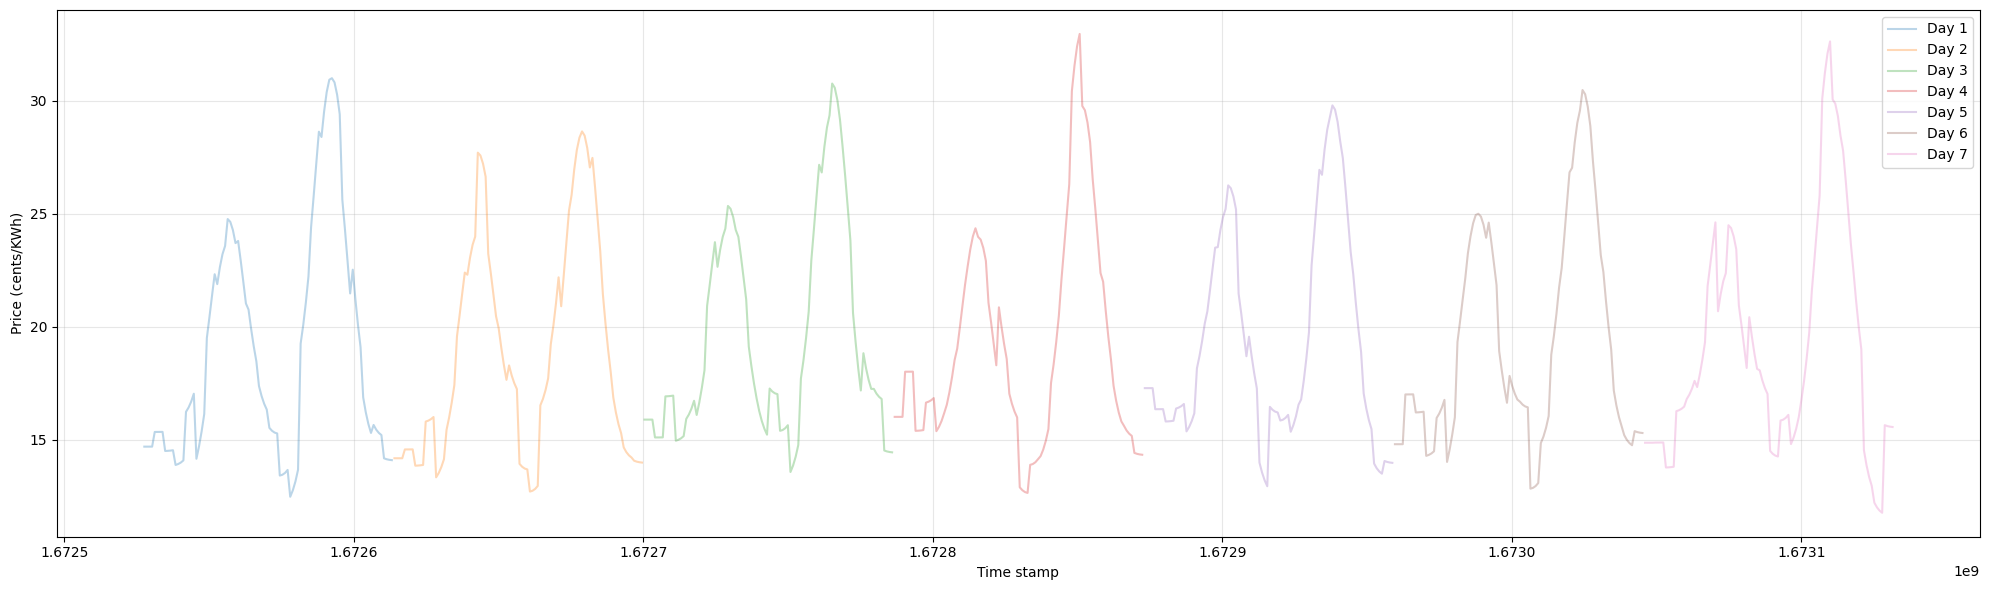

In [3]:
plt.figure(figsize=(20, 6))
# get timestamp for a specific date
ts = datetime.datetime(2023, 1, 1).timestamp()
resolution = 15 # minutes
for d in range(7):
    tss = []
    eps = []
    for lt in range(24*60//resolution):
        time = ts + d*24*60*60 + lt*resolution*60
        ep = gen_EP(seed=RANDOM_SEED + d, ts=time)
        tss.append(time)
        eps.append(ep)
    plt.plot(tss, eps, alpha=0.3, label = f"Day {d+1}")

# set fig size
plt.xlabel('Time stamp')
plt.ylabel('Price (cents/KWh)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

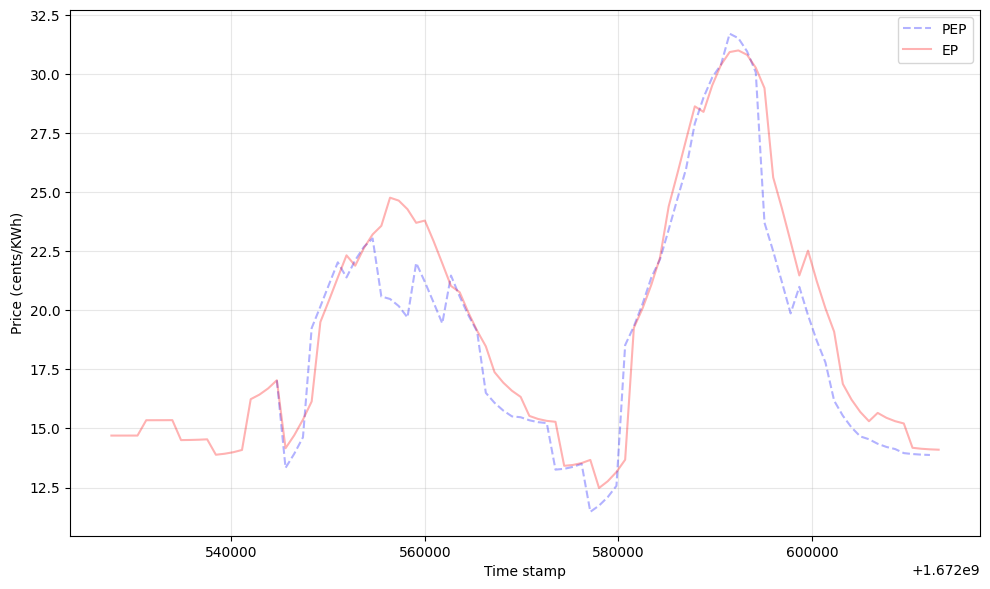

In [4]:
plt.figure(figsize=(10, 6))
# get timestamp for a specific date
ts = datetime.datetime(2023, 1, 1).timestamp()
resolution = 15 # minutes

tss = []
eps = []
for lt in range(24*60//resolution):
    time = ts + lt*resolution*60
    ep = gen_EP(seed=RANDOM_SEED, ts=time)
    tss.append(time)
    eps.append(ep)

ts_index = int(len(tss)*0.2) # pick a time in the day at approximately 10% through
ts = tss[ts_index]
cp = eps[ts_index] # get corresponding price as current price
ptss = [ts]
peps = [cp]
for lt in range(ts_index+1, len(tss)-1):
    time = tss[lt]
    cp = eps[lt]
    pep = gen_PEP(RANDOM_SEED, time, cp, resolution)
    ptss.append(time)
    peps.append(pep)
plt.plot(ptss, peps, alpha=0.3, label = f"PEP", linestyle='dashed', color = 'blue')
plt.plot(tss, eps, alpha=0.3, label = f"EP", linestyle='solid', color = 'red')

# set fig size
plt.xlabel('Time stamp')
plt.ylabel('Price (cents/KWh)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

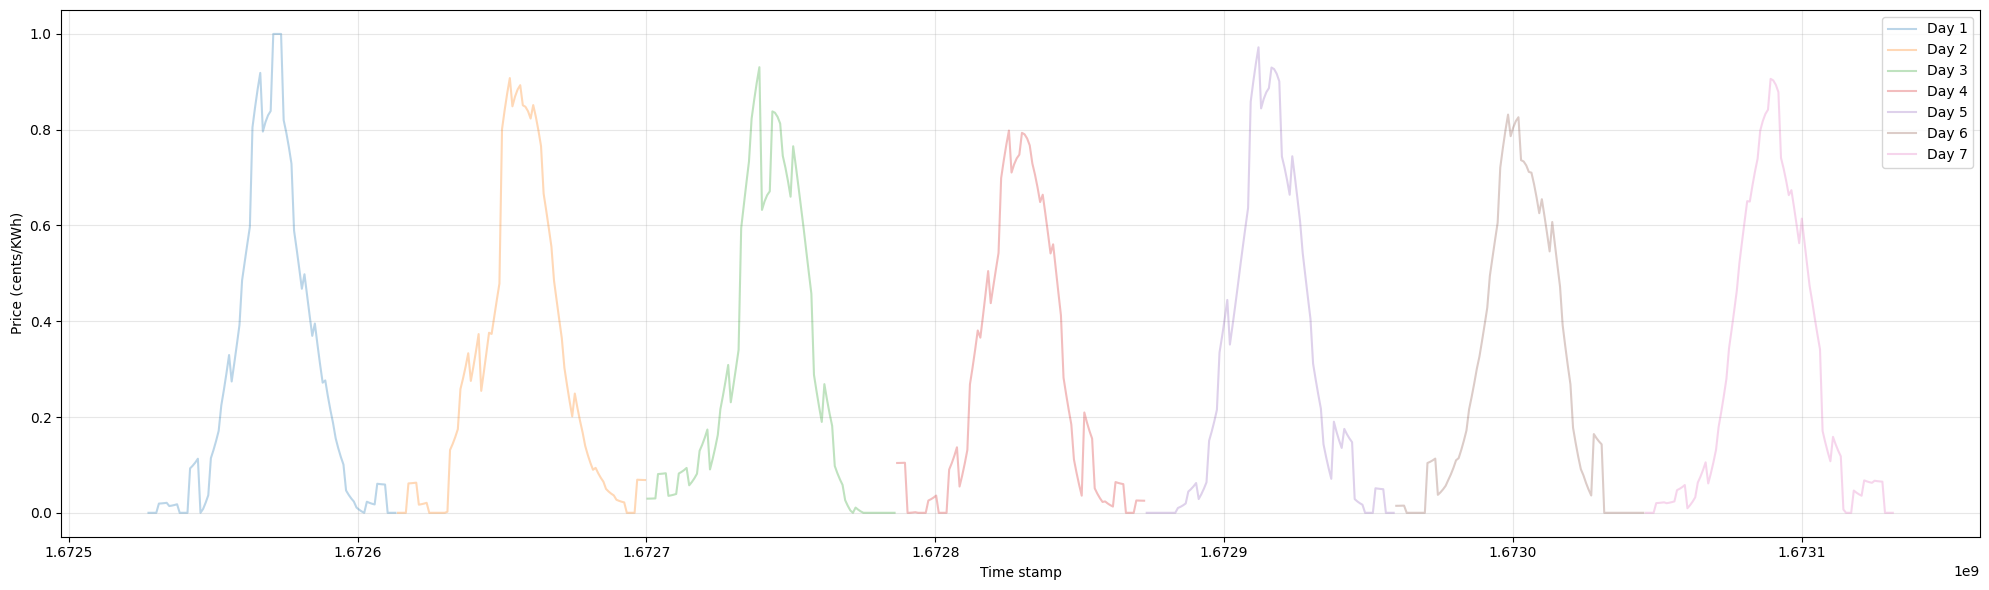

In [5]:
plt.figure(figsize=(20, 6))
# get timestamp for a specific date
ts = datetime.datetime(2023, 1, 1).timestamp()
resolution = 15 # minutes
for d in range(7):
    tss = []
    eps = []
    for lt in range(24*60//resolution):
        time = ts + d*24*60*60 + lt*resolution*60
        ep = gen_PVShare(seed=RANDOM_SEED + d, ts=time)
        tss.append(time)
        eps.append(ep)
    plt.plot(tss, eps, alpha=0.3, label = f"Day {d+1}")
# set fig size
plt.xlabel('Time stamp')
plt.ylabel('Price (cents/KWh)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

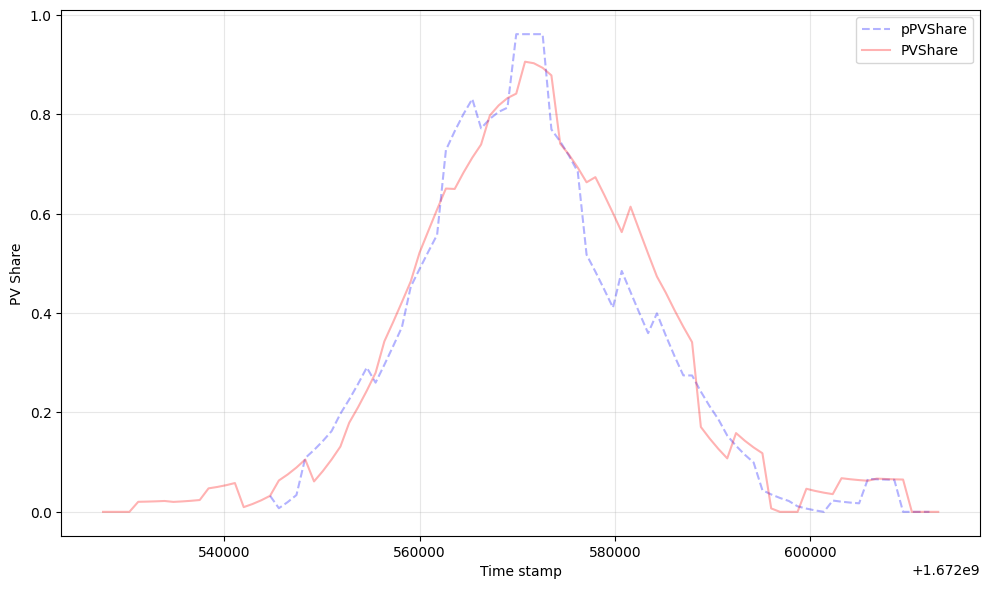

In [6]:
plt.figure(figsize=(10, 6))
# get timestamp for a specific date
ts = datetime.datetime(2023, 1, 1).timestamp()
resolution = 15 # minutes

tss = []
PVs = []
for lt in range(24*60//resolution):
    time = ts + lt*resolution*60
    PVShare = gen_PVShare(seed=RANDOM_SEED, ts=time)
    tss.append(time)
    PVs.append(ep)

ts_index = int(len(tss)*0.2) # pick a time in the day at approximately 10% through
ts = tss[ts_index]
cPVShare = eps[ts_index] # get corresponding price as current price
ptss = [ts]
pPVs = [cPVShare]
for lt in range(ts_index+1, len(tss)-1):
    time = tss[lt]
    cPVShare = eps[lt]
    pPV = gen_PVShareP(RANDOM_SEED, time, cPVShare, resolution)
    ptss.append(time)
    pPVs.append(pPV)
plt.plot(ptss, pPVs, alpha=0.3, label = f"pPVShare", linestyle='dashed', color = 'blue')
plt.plot(tss, eps, alpha=0.3, label = f"PVShare", linestyle='solid', color = 'red')

# set fig size
plt.xlabel('Time stamp')
plt.ylabel('PV Share')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Binary Charging Signal: [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]


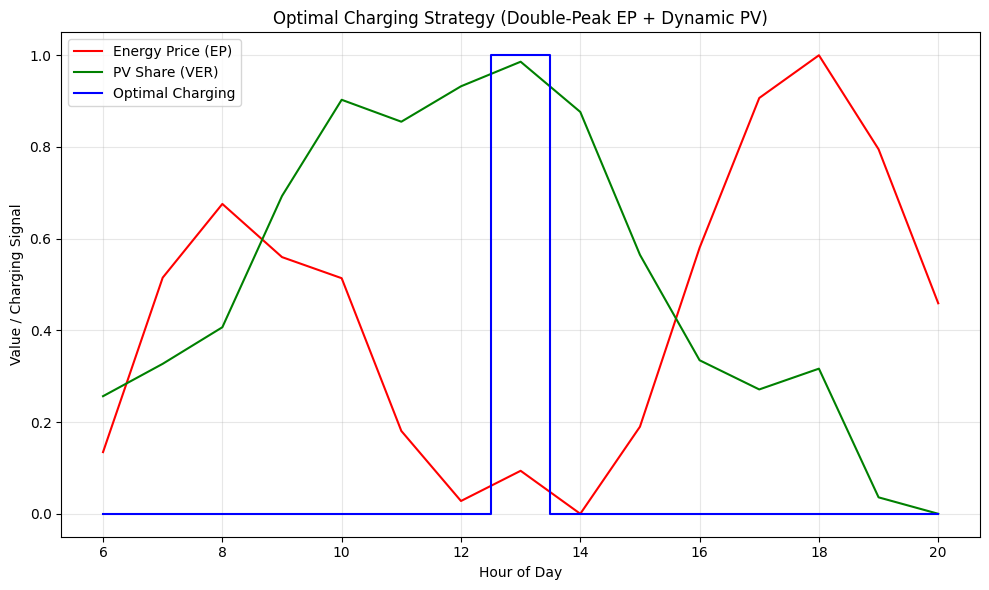

In [7]:
import numpy as np

np.random.seed(RANDOM_SEED)
hours = np.arange(6, 21)  # 6:00 to 20:00

# -----------------------------
# Energy Price (EP) - double peak + fluctuations
# -----------------------------
morning_peak = 20 * np.exp(-0.5 * ((hours - 8)/1.5)**2)
evening_peak = 25 * np.exp(-0.5 * ((hours - 18)/2)**2)
base_price = 50 + morning_peak + evening_peak

# Add dynamic fluctuations
fluctuation = 3 * np.sin(0.8 * hours) + np.random.normal(0, 2, size=hours.shape)
ep = base_price + fluctuation
ep = (ep - np.min(ep)) / (np.max(ep) - np.min(ep))  # normalize 0-1

# -----------------------------
# PV Share (VER) - more dynamic
# -----------------------------
ver = np.exp(-0.5 * ((hours - 12)/3)**2)
ver = ver + 0.1 * np.sin(1.5 * hours) + np.random.normal(0, 0.05, size=hours.shape)
ver = np.clip(ver, 0, 1)

# -----------------------------
# Optimal Charging Strategy
# -----------------------------
ep_threshold = 0.2
ver_threshold = 0.94
charge = np.where((ep < ep_threshold) & (ver > ver_threshold), 1, 0)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10, 6))
plt.plot(hours, ep, 'r-', label='Energy Price (EP)')
plt.plot(hours, ver, 'g-', label='PV Share (VER)')
plt.step(hours, charge, 'b-', where='mid', label='Optimal Charging')
plt.title('Optimal Charging Strategy (Double-Peak EP + Dynamic PV)')
plt.xlabel('Hour of Day')
plt.ylabel('Value / Charging Signal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

print("Binary Charging Signal:", charge)

# save the figure as SVG with high resolution
#plt.savefig('optimal_charging_strategy.svg', format='svg', dpi=300)
plt.show()

